<a href="https://colab.research.google.com/github/SkyWarLimit/PemMes_17/blob/main/JS06/JS06_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.svm import SVC

In [2]:
# buat sebuah fungsi untuk menampilkan fitting data

def plot_svc_decision_function(model, ax=None, plot_support=True):

    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # buat grid untuk evaluasi model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot batas dan margin
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

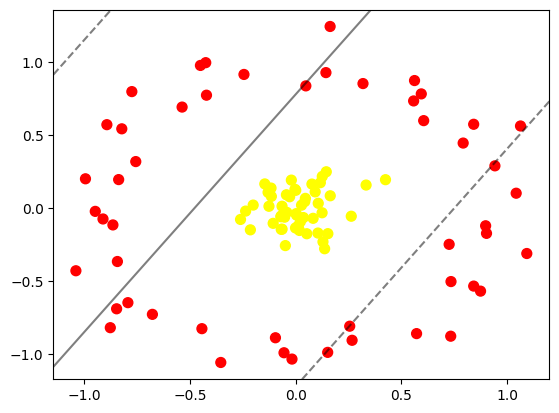

In [3]:
# contoh data tidak terpisah secara linier
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

In [5]:
r = np.exp(-(X**2).sum(1))

In [6]:
from mpl_toolkits import mplot3d
from ipywidgets import interact, fixed

def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azip=(-180, 180),
         X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[ 1.62658655e-01,  1.24574433e+00],
       [ 4.56340230e-02,  6.68071665e-02],
       [-1.03938515e+00, -4.29725561e-01],
       [-2.86861614e-02,  7.78927041e-02],
       [ 2.66553922e-01, -9.06594486e-01],
       [ 2.30404550e-03, -3.79520928e-02],
       [ 2.75644313e-02,  2.01056820e-02],
       [-8.37164732e-01,  1.95581614e-01],
       [-1.16736358e-01,  1.37397008e-01],
       [ 6.05086809e-01,  5.99947250e-01],
       [ 1.36766000e-01, -2.78630539e-01],
       [-5.25851719e-02, -6.22889649e-02],
       [ 1.05120185e-01, -1.71081360e-01],
       [-1.30738623e-01,  1.08361936e-01],
       [ 2.55331992e-01, -8.09944530e-01],
       [ 2.62638981e-01, -5.57312642e-02],
       [-8.46824128e-01, -6.90599514e-01],
       [ 4.24531658e-01,  1.94922897e-01],
       [-8.94303036e-04, -1.36119863e-01],
       [-1.06667104e-01, -1.04404035e-01],
       [-6.46974094e-02,  1.29313443e-02],
       [ 1.42849264e-01,  9.29304776e-01],
       [ 8.73907428e-01, -5.69426227e-01],
       [ 4.28584014e-02,  4.50906241e-02],
       [ 7.91747106e-01,  4.46146770e-01],
       [-2.01159663e-01,  2.07493695e-02],
       [-6.43935849e-02, -1.44486416e-01],
       [ 1.63251745e-01,  8.45659121e-02],
       [-9.11215379e-01, -7.45655531e-02],
       [-9.58942969e-02, -8.89246572e-01],
       [-4.43530998e-01, -8.26929694e-01],
       [-4.50509845e-01,  9.78513565e-01],
       [ 9.19539027e-02,  1.11209783e-01],
       [ 1.28867985e-01, -2.31139911e-01],
       [ 1.24675442e-01, -3.20203787e-02],
       [ 5.57579811e-01,  7.35041096e-01],
       [ 1.51200738e-01, -9.89388117e-01],
       [ 3.64033211e-02, -6.48475110e-02],
       [ 1.04240844e+00,  1.02118514e-01],
       [ 7.34228913e-01, -5.03869740e-01],
       [-2.36819099e-01, -2.03914661e-02],
       [-1.26521457e-01,  1.25967229e-02],
       [-9.47751700e-01, -2.23965845e-02],
       [-5.53494285e-02, -9.92101307e-01],
       [-8.76677823e-01, -8.20189801e-01],
       [-6.77625785e-01, -7.28721097e-01],
       [-2.14367188e-01, -1.49013052e-01],
       [ 9.02161168e-01, -1.73227854e-01],
       [ 1.24200274e-02, -1.20560895e-01],
       [-4.39367733e-02,  9.14588986e-02],
       [-2.44716345e-01,  9.16710791e-01],
       [-7.93489880e-01, -6.48553537e-01],
       [-7.04117984e-02, -5.92141367e-02],
       [ 7.25483005e-01, -2.48516754e-01],
       [-1.15180838e-01,  8.02761319e-02],
       [ 8.23228206e-02, -6.99768020e-02],
       [ 4.78896380e-02,  8.38252203e-01],
       [ 7.32914865e-01, -8.78563505e-01],
       [-7.74813748e-01,  7.99083371e-01],
       [ 5.23579422e-02, -1.75915047e-01],
       [ 3.32785876e-01,  1.58169934e-01],
       [ 1.75523558e-02, -1.53336722e-01],
       [-4.21256942e-02, -2.93747872e-02],
       [-2.06791579e-02,  1.91994634e-01],
       [-6.85715856e-02, -5.41308043e-02],
       [ 1.25557332e-01,  2.17283028e-01],
       [-3.54248291e-01, -1.05878997e+00],
       [-4.21895316e-01,  7.74416460e-01],
       [-3.42039026e-03,  1.28851638e-01],
       [-7.56273732e-01,  3.19125721e-01],
       [ 7.65779762e-02,  1.64817431e-01],
       [-4.89704619e-02, -2.57077523e-01],
       [ 4.20473339e-03, -4.82295819e-02],
       [-5.37232238e-01,  6.92930766e-01],
       [-8.22344848e-01,  5.43792922e-01],
       [-9.94091052e-01,  2.01058377e-01],
       [ 1.44493688e-01,  2.49180327e-01],
       [-8.92906224e-01,  5.72254241e-01],
       [-8.64359808e-01, -1.15361983e-01],
       [ 1.06477532e-01,  3.30748943e-02],
       [-1.76426111e-02, -1.03547002e+00],
       [ 8.41611666e-01, -5.34903114e-01],
       [ 1.09265137e+00, -3.11418462e-01],
       [-1.46136548e-01,  1.65846233e-01],
       [ 9.41881967e-01,  2.89851193e-01],
       [-8.43134772e-01, -3.66291814e-01],
       [-6.84738471e-02, -1.45707373e-01],
       [ 1.06294031e+00,  5.63315358e-01],
       [ 8.97993150e-01, -1.21210722e-01],
       [-2.60949630e-01, -7.78596358e-02],
       [ 1.51983184e-01, -1.75297600e-01],
       [ 3.18095396e-01,  8.54222836e-01

In [7]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)

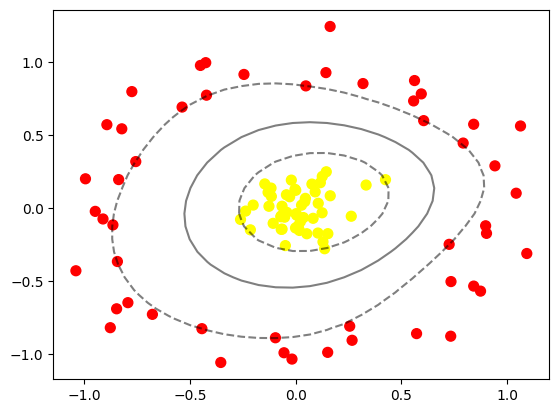

In [8]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none')